# Practical Assignment I: Multilayer Perceptrons

Multilayer perceptron (MLP) is a fully connected, feedforward neural network architecture. It consists of one input layer, one or more hidden layers, and one output layer. Each layer consists of units (also called neurons, or nodes).

Each unit is connected to every unit in a neighboring layer, hence fully connected. This is why in Keras these layers are called `Dense`. Information flows from left to right, hence feedforward.

<img src="https://edirlei.com/images/nn1.png" width="800">

**Learning objectives:**

At the end of this DataLab, you will be able to build MLPs using Keras for the following problem types:

 - Regression
 - Binary classification
 - Multi-class classification
 - Multi-label classification
 
For each type, you will be given a suitable dataset. Then you will:

 - Pre-process the data if needed
 - Create a `Sequential()` model
 - Compile the model by defining a loss function, an optimizer and the metrics to be calculated
 - Train the model using the `fit()` method
 - Test the model using the `predict()` and `evaluate()` methods
 
 
 **Notebook contents:**
 
 1. Regression
 2. Binary classification
 3. Multi-class classification
 4. Multi-label classification

**Packages:**

Let's start by importing the basic packages required for this DataLab:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Regression

The goal of a regression task is to predict a continuous outcome variable (dependent variable) based on one or more predictor variables (independent variables).

**The dataset**

In this task, you will use the diabetes dataset provided by `scikit-learn`.

Please read the dataset documentation before you start:

https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

Now let's load the data and display some samples from the dataset:

In [2]:
from sklearn import datasets
diabetes = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target
names = diabetes.feature_names
Xy_combined = np.concatenate((X, y[:, np.newaxis]), axis=1)
df = pd.DataFrame(Xy_combined,
                  columns=names + ['disease progression'])
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Let's split the dataset into a training set and a testing set using function ``train_test_split``:

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.30,
                                                    random_state=0)

Now we can visualize the dimensions of the sets:

In [4]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((309, 10), (133, 10), (309,), (133,))

**Task 1.1**
Build an MLP suitable for the diabetes dataset. Use a `Sequential()` model and `Dense` layers from Keras. You are free to pick any number of hidden layers and any number of units per layer as long as it works.  Use suitable activation functions.

In [5]:
# YOUR CODE HERE #
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(64, input_dim=10, activation='relu'))  # First hidden layer
model.add(Dense(32, activation='relu'))                            # Second hidden layer
model.add(Dense(1, activation='linear'))                           # Output layer for regression



**Task 1.2**
Using `model.compile()`, compile the model. Select a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [6]:
# YOUR CODE HERE #
model.compile(optimizer='adam', loss='mse')  # Using Mean Squared Error for regression

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                704       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,817
Trainable params: 2,817
Non-trainable params: 0
_________________________________________________________________


**Task 1.3** Using `model.fit()` Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [7]:
# YOUR CODE HERE #
model.fit(X_train, y_train, epochs=50)

Epoch 1/50
10/10 [==============================] - 0s 1ms/step - loss: 29402.0938
Epoch 2/50
10/10 [==============================] - 0s 1000us/step - loss: 29352.5332
Epoch 3/50
10/10 [==============================] - 0s 1ms/step - loss: 29282.3008
Epoch 4/50
10/10 [==============================] - 0s 889us/step - loss: 29183.4922
Epoch 5/50
10/10 [==============================] - 0s 795us/step - loss: 29039.2871
Epoch 6/50
10/10 [==============================] - 0s 778us/step - loss: 28836.3848
Epoch 7/50
10/10 [==============================] - 0s 778us/step - loss: 28560.7871
Epoch 8/50
10/10 [==============================] - 0s 889us/step - loss: 28194.7344
Epoch 9/50
10/10 [==============================] - 0s 889us/step - loss: 27725.5020
Epoch 10/50
10/10 [==============================] - 0s 777us/step - loss: 27140.6270
Epoch 11/50
10/10 [==============================] - 0s 778us/step - loss: 26406.6230
Epoch 12/50
10/10 [==============================] - 0s 778us/step

**Task 1.4** Evaluate the model using `model.evaluate()`.

In [8]:
# YOUR CODE HERE #
model.evaluate(X_test, y_test)

5/5 [==============================] - 0s 2ms/step - loss: 3277.0034


3277.00341796875

**Task 1.5** Get predictions on `X_test`. Plot `y_test` vs. predictions. On the same plot, plot a $x = y$ line. Think about what this line represents.

5/5 [==============================] - 0s 1ms/step


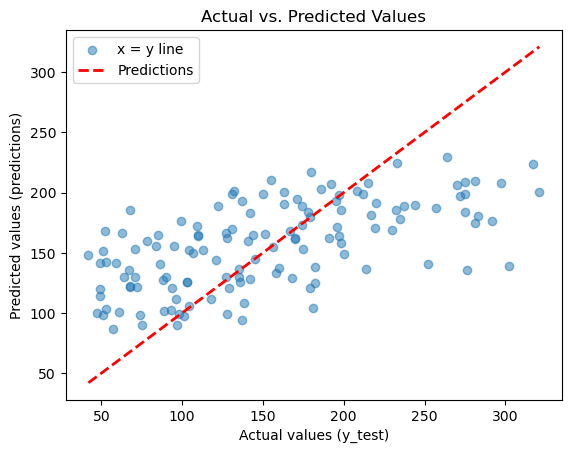

In [9]:
# YOUR CODE HERE #
import matplotlib.pyplot as plt
predictions = model.predict(X_test)
plt.scatter(y_test, predictions, alpha=0.5)
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual values (y_test)')
plt.ylabel('Predicted values (predictions)')

# Plot x = y line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.legend(['x = y line', 'Predictions'])
plt.show()

## 2. Binary Classification

Binary classification is a type of classification where a model is trained to categorize data points into one of two categories. 

**The dataset**

In this task, you will use the breast cancer dataset provided by `scikit-learn`.

Please read the dataset documentation before you start:

https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset

Now let's load the data and display some samples from the dataset:

In [10]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
names = list(cancer.feature_names)
Xy_combined = np.concatenate((X, y[:, np.newaxis]), axis=1)
df = pd.DataFrame(Xy_combined,
                  columns=names + ['Benign'])
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Benign
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


Let's split the dataset into a training set and a testing set using function ``train_test_split``:

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.30,
                                                    random_state=0)

Now we can visualize the dimensions of the sets:

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((398, 30), (171, 30), (398,), (171,))

**Task 2.1**
Build an MLP suitable for the breast cancer dataset. Use a `Sequential()` model and `Dense` layers from Keras. You are free to pick any number of hidden layers and any number of units per layer as long as it works. Use suitable activation functions.

In [13]:
# YOUR CODE HERE #
model = Sequential()
model.add(Dense(1, input_shape=(30,), activation="sigmoid"))

**Task 2.2**
Compile the model by selecting a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [14]:
# YOUR CODE HERE #
model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 1)                 31        
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


**Task 2.3**
Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [15]:
# YOUR CODE HERE #
model.fit(X_train, y_train, epochs = 40)

Epoch 1/40


13/13 [==============================] - 0s 1ms/step - loss: 1660.9209 - accuracy: 0.4598
Epoch 2/40
13/13 [==============================] - 0s 667us/step - loss: 1266.8300 - accuracy: 0.5000
Epoch 3/40
13/13 [==============================] - 0s 704us/step - loss: 1089.5392 - accuracy: 0.5452
Epoch 4/40
13/13 [==============================] - 0s 640us/step - loss: 1001.2706 - accuracy: 0.5804
Epoch 5/40
13/13 [==============================] - 0s 750us/step - loss: 1147.8911 - accuracy: 0.5251
Epoch 6/40
13/13 [==============================] - 0s 917us/step - loss: 1016.7343 - accuracy: 0.5402
Epoch 7/40
13/13 [==============================] - 0s 1ms/step - loss: 776.0231 - accuracy: 0.5528
Epoch 8/40
13/13 [==============================] - 0s 834us/step - loss: 688.6990 - accuracy: 0.5804
Epoch 9/40
13/13 [==============================] - 0s 2ms/step - loss: 400.5106 - accuracy: 0.6508
Epoch 10/40
13/13 [==============================] - 0s 1ms/step - loss: 261.1238 - accuracy:

**Task 2.4**
Evaluate the model using `model.evaluate()`.

In [16]:
# YOUR CODE HERE #
accuracy = model.evaluate(X_test, y_test)[1]


6/6 [==============================] - 0s 1000us/step - loss: 47.7308 - accuracy: 0.9006


**Task 2.5**
Plot the confusion matrix for your trained model on the test set.

6/6 [==============================] - 0s 1ms/step


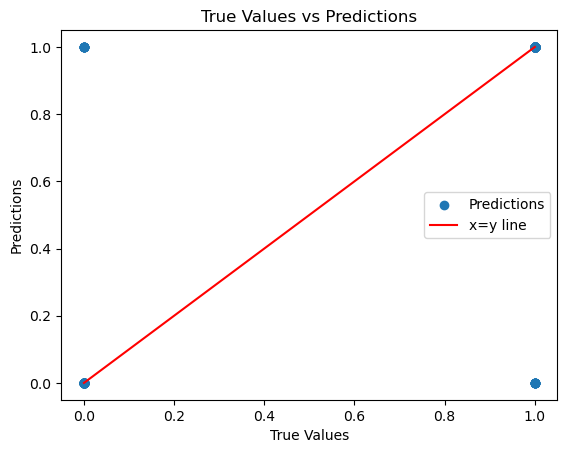

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'model' is your trained model
predictions = model.predict(X_test)

# Scatter plot of y_test vs predictions
plt.scatter(y_test, predictions, label='Predictions')

# Plot x = y line
plt.plot(y_test, y_test, color='red', label='x=y line')

# Adding labels, title and legend
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True Values vs Predictions')
plt.legend()

# Display the plot
plt.show()

## 3. Multi-class Classification

Multi-class classification is a task where an instance or sample can be classified into more than two categories or classes.

**The dataset**

In this task, you will use the MNIST dataset provided by `keras`.

Please read the dataset documentation before you start:

https://keras.io/api/datasets/mnist/

Now let's load the dataset (notice that function ``mnist.load_data`` automatizally splits the data into a training set and a testing set):

In [18]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

To visualize how the samples look like, we can display a random sample from the dataset:

Label: 6


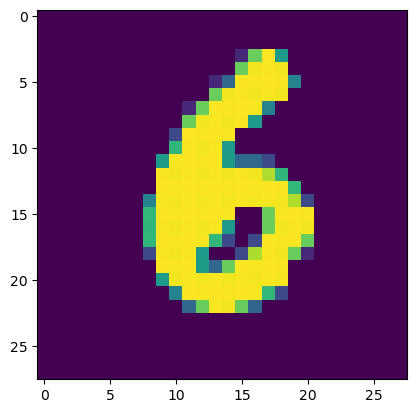

In [19]:
# View random digit
index = np.random.randint(0, 60000)
plt.imshow(X_train[index])
print('Label:', y_train[index])

We can also visualize the dimensions of the sets:

In [20]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

**Task 3.1**
The MLP architecture you will build is given below. 784 input units, two hidden layers with 30 units each, one output layer with 10 units. 

<img src="https://edirlei.com/images/nn2.png" width="500">

**Important**: Notice that X_train/X_test shape and the input layer shape of the network are not compatible (X_train shape is ``(, 28, 28)``, but the expected input layer shape is ``(, 784)``). Similarly, y_train/y_test and the output layer shape of the network, are not compatible (y_train shape is ``(,1)``, but the expected output layer shape is ``(,10)``). To solve this problem, you need to preprocess the data to make them compatible. Here are some hints on how to solve this problem:

- You can solve the incompatibility of the input by using the [reshape function](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html).
- You can solve the incompatibility of the output by using one-hot encoding through the [to_categorical function](https://www.tensorflow.org/api_docs/python/tf/keras/utils/to_categorical).



In [21]:
# YOUR CODE HERE #
from keras.utils import to_categorical
import numpy as np

# Reshape X_train and X_test to (, 784)
X_train = X_train.reshape((X_train.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))

# One-hot encode y_train and y_test to (, 10)
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

**Task 3.2**
Build an MLP suitable for the MNIST dataset. Use a `Sequential()` model and `Dense` layers from Keras. Build the architecture shown in Task 3.1 Use suitable activation functions.

In [22]:
# YOUR CODE HERE #

# Create a Sequential model
model = Sequential()

# Add the first Dense layer with suitable activation function (e.g., ReLU)
model.add(Dense(512, input_shape=(784,), activation='relu'))

# Add the second Dense layer
model.add(Dense(256, activation='relu'))

# Add the third Dense layer
model.add(Dense(128, activation='relu'))

# Add the output layer with 10 neurons (for the 10 classes) using softmax activation function
model.add(Dense(10, activation='softmax'))

**Task 3.3**
Compile the model by selecting a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [23]:
# YOUR CODE HERE #
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

**Task 3.4**
Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [24]:
history = model.fit(X_train, y_train, 
                    epochs=10, 
                    batch_size=32, 
                    validation_data=(X_test, y_test))

Epoch 1/10


1875/1875 [==============================] - 6s 3ms/step - loss: 0.9885 - accuracy: 0.9002 - val_loss: 0.2161 - val_accuracy: 0.9426
Epoch 2/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1866 - accuracy: 0.9476 - val_loss: 0.2034 - val_accuracy: 0.9466
Epoch 3/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1522 - accuracy: 0.9567 - val_loss: 0.1812 - val_accuracy: 0.9519
Epoch 4/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1305 - accuracy: 0.9633 - val_loss: 0.1266 - val_accuracy: 0.9670
Epoch 5/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1131 - accuracy: 0.9688 - val_loss: 0.1082 - val_accuracy: 0.9693
Epoch 6/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1016 - accuracy: 0.9720 - val_loss: 0.1737 - val_accuracy: 0.9550
Epoch 7/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0919 - accuracy: 0.9757 - val_loss: 0.1290 - val_accuracy: 0.9683
Epo

**Task 3.5**
Evaluate the model using `model.evaluate()`.

In [25]:
# YOUR CODE HERE #
accuracy = model.evaluate(X_test, y_test)[1]

  1/313 [..............................] - ETA: 5s - loss: 0.0353 - accuracy: 0.9688

313/313 [==============================] - 0s 1ms/step - loss: 0.1205 - accuracy: 0.9725


**Challenge:**
Find the worst prediction. If you struggle with this task, try it later.

In [26]:
# YOUR CODE HERE #
import numpy as np

# Get the model's predictions
predictions = model.predict(X_test)

# Convert predictions from categorical back to original labels
predicted_labels = np.argmax(predictions, axis=1)

# Convert y_test from categorical back to original labels
true_labels = np.argmax(y_test, axis=1)

# Calculate the difference between predicted and true labels
diff = predicted_labels - true_labels

# Find the index of the worst prediction
worst_index = np.argmax(np.abs(diff))

print("Index of worst prediction:", worst_index)
print("Predicted label:", predicted_labels[worst_index])
print("True label:", true_labels[worst_index])

313/313 [==============================] - 0s 1ms/step
Index of worst prediction: 6505
Predicted label: 0
True label: 9


## 4. Multi-label Classification

Multi-label classification is a type of classification where an instance (or data point) can be classified into multiple classes or categories simultaneously. This is different from multi-class classification, where each instance is assigned to only one class.

**The dataset**

In this task you will use a simulated dataset.

You are given 4 random integers ($x_1, x_2, x_3, x_4$) between -5 and 5 ($x_i \in [-5, 5]$). Your task is to develop an MLP that predicts parity and sign of the product of these four numbers ($x_1 \times x_2 \times x_3 \times x_4$).

**Definitions**

In mathematics, parity is the property of an integer of whether it is even or odd.

In mathematics, the sign of a real number is its property of being either positive, negative, or zero.

**Example**

$x_1=-1, x_2=1, x_3=-3, x_4=-5$

$ product = x_1 \times x_2 \times x_3 \times x_4 = -15$

parity of -15 is `odd` and sign of -15 is `negative`.

**Columns**

$x_i$: Integers between -5 (inclusive) and 5 (inclusive).

Parity column: $x_1 \times x_2 \times x_3 \times x_4$ is even (0) or odd (1).

Sign column: $x_1 \times x_2 \times x_3 \times x_4$ is negative (-1), or zero (0) or positive (1).

|$x_1$|$x_2$|$x_3$|$x_4$|$Parity$|$Sign$|
|:--|:--|:--|:--|:--|:--|
|-2|-4|-1|1|0|-1|
|-3|5|-3|3|1|1|
|-4|-2|5|3|0|1|
|-4|0|-5|0|0|0|
|1|1|2|-4|0|-1|
|-1|1|-3|-5|1|-1|


Based on these definitions, we can write a function to generate a simulated dataset:

In [27]:
def simulator(n):
    
    # x_i numbers with shape (n, 4)
    X = np.random.randint(-5, 6, size=(n, 4))

    # product of 4 numbers for each row
    # this will be used to calculate labels
    # but this won't be part of the dataset
    product = np.prod(X, axis=1)

    # label 1
    parity_col = product % 2
    parity_col = parity_col.reshape(-1, 1)

    # label 2
    pos = (product > 0)*1
    neg = (product < 0)*-1
    zero = (product == 0)*0
    sign_col = pos + neg + zero
    sign_col = sign_col.reshape(-1, 1)

    # concatenate columns to create the dataset
    dataset = np.concatenate((X, parity_col, sign_col), axis=1)
    
    return dataset

Now we can create the dataset:

In [28]:
dataset = simulator(n=10000)

To see how the data look like, we can display some samples from the dataset:

In [29]:
df = pd.DataFrame(dataset, columns=['x_1', 'x_2', 'x_3', 'x_4', 'Parity', 'Sign'])
df.head(10)

,x_1,x_2,x_3,x_4,Parity,Sign
0,1,-3,-3,0,0,0
1,0,1,-1,-5,0,0
2,-5,5,1,4,0,-1
3,1,0,-1,-5,0,0
4,2,-3,-4,4,0,1
5,4,4,-4,-2,0,1
6,4,-4,-3,-1,0,-1
7,-2,3,-1,2,0,1
8,5,1,1,0,0,0
9,-5,5,4,-2,0,1


**Task 4.1**
Use the numpy array `dataset` to create `X` and `y`. Preprocess the data if needed.

In [30]:
# YOUR CODE HERE #
X = dataset[:, :4]
y = dataset[:, 4:]


After preprocessing the data, we can split the dataset into a training set and a testing set using function ``train_test_split``:

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.30,
                                                    random_state=0)

Then we can visualize the dimensions of the sets:

In [32]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7000, 4), (7000, 2), (3000, 4), (3000, 2))

**Task 4.2**
Build a MLP suitable for this simulated dataset. Use a `Sequential()` model and `Dense` layers from Keras. Use suitable activation functions.

In [33]:
# YOUR CODE HERE #
model = Sequential()
model.add(Dense(32, input_dim=4, activation='relu'))  
model.add(Dense(32, activation='relu'))  
model.add(Dense(2, activation='sigmoid'))

**Task 4.3**
Compile the model by selecting a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [34]:
# YOUR CODE HERE #
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

**Task 4.4**
Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [35]:
# YOUR CODE HERE #
history = model.fit(X_train, y_train, epochs=30)

Epoch 1/30


219/219 [==============================] - 0s 777us/step - loss: 0.1356 - accuracy: 0.6627
Epoch 2/30
219/219 [==============================] - 0s 764us/step - loss: -0.2606 - accuracy: 0.7080
Epoch 3/30
219/219 [==============================] - 0s 815us/step - loss: -1.4660 - accuracy: 0.7243
Epoch 4/30
219/219 [==============================] - 0s 826us/step - loss: -4.6840 - accuracy: 0.7170
Epoch 5/30
219/219 [==============================] - 0s 829us/step - loss: -11.2444 - accuracy: 0.7166
Epoch 6/30
219/219 [==============================] - 0s 795us/step - loss: -22.2390 - accuracy: 0.7180
Epoch 7/30
219/219 [==============================] - 0s 824us/step - loss: -39.1170 - accuracy: 0.7144
Epoch 8/30
219/219 [==============================] - 0s 776us/step - loss: -62.3961 - accuracy: 0.7156
Epoch 9/30
219/219 [==============================] - 0s 778us/step - loss: -92.2833 - accuracy: 0.7156
Epoch 10/30
219/219 [==============================] - 0s 781us/step - loss: -13